In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
COMPASS Pretraining Script
--------------------------
This script performs unsupervised pretraining of the COMPASS model 
on TCGA transcriptomic data (subset of genes for efficiency). 
It uses the Performer encoder and standard contrastive/masked 
representation learning objectives.

"""


# =========================================================
# 1. Environment setup
# =========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # Specify which GPU to use


In [3]:
# =========================================================
# 2. Install and check COMPASS
# =========================================================
#get_ipython().system('pip install immuno-compass -U')  # Ensure latest COMPASS version

import compass
print("Using COMPASS version:", compass.__version__)

Using COMPASS version: 2.5


In [4]:
# =========================================================
# 3. Define output directory
# =========================================================
save_dir = './results/PT'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [5]:
# =========================================================
# 4. Import core modules
# =========================================================
from compass import loadcompass
from compass import PreTrainer, FineTuner
from compass.tokenizer import CANCER_CODE
from compass.utils import plot_performance, score2
import pandas as pd
import numpy as np

get_ipython().run_line_magic('matplotlib', 'inline')

In [6]:
# =========================================================
# 5. Data loading function
# =========================================================
_GLOBALS = {}

def load_tcga(path):
    """
    Load TCGA transcriptomic and label tables.

    Parameters
    ----------
    path : str
        Path to the folder containing 'TCGA.TPM.TABLE' and 
        'TCGA.PATIENT.PROCESSED.TABLE' files.

    Returns
    -------
    df_tpm : pd.DataFrame
        TPM-normalized gene expression matrix.
    df_label : pd.DataFrame
        Corresponding patient-level metadata.
    """
    if "df_tpm" not in _GLOBALS:
        _GLOBALS["df_tpm"] = pd.read_pickle(os.path.join(path, "TCGA.TPM.TABLE"))
        _GLOBALS["df_label"] = pd.read_pickle(os.path.join(path, "TCGA.PATIENT.PROCESSED.TABLE"))
    return _GLOBALS["df_tpm"], _GLOBALS["df_label"]

In [9]:
# =========================================================
# 6. Prepare data for pretraining
# =========================================================
# Use a subset of genes for faster training (full TCGA gene set is large)
tcga_path = './data/TCGA/1065'

df_tpm, df_label = load_tcga(tcga_path)

# Encode cancer types numerically
df_cancer = df_label[["cancer_type"]]
dfcx = (
    df_cancer.cancer_type
    .apply(lambda x: x.replace("TCGA-", ""))
    .map(CANCER_CODE)
    .to_frame("cancer_code")
    .join(df_tpm)
)

# Stratified split by cancer type (90% train / 10% test)
test_idx = df_cancer.groupby("cancer_type").apply(
    lambda x: x.sample(frac=0.1, random_state=123).index.tolist()
).sum()
train_idx = df_cancer[~df_cancer.index.isin(test_idx)].index

dfcx_train, dfcx_test = dfcx.loc[train_idx], dfcx.loc[test_idx]
print("Training set:", dfcx_train.shape, "| Test set:", dfcx_test.shape)


Training set: (9166, 1066) | Test set: (1018, 1066)


In [10]:
# =========================================================
# 7. Define training configuration
# =========================================================

model_args = {
    'lr': 1e-3,              # Adjust to 1e-4 when using all genes
    'epochs': 100,
    'batch_size': 1024,      # Reduce if memory is limited
    'seed': 42,
    'patience': 10,
    'encoder': 'performer',  # Use performer or transformer encoder for efficient attention
    'weight_decay': 1e-7,
    'triplet_margin': 1.0,
    'batch_correction': 0.1,
}

data_args = {
    'no_augment_prob': 0.1,  # Probability of skipping augmentation, lower is better, can be zero.
    'mask_p_prob': 0.7,      # Probability of masking positive samples, higher is better
    'mask_n_prob': 0.0,
    'mask_a_prob': 0.0,
    'jitter_a_std': 0.0,
    'jitter_n_std': 0.0,
    'jitter_p_std': 0.4,     # Additive noise for feature perturbation, 0-0.5
}

pretrainer = PreTrainer(**model_args, work_dir=save_dir)

Epoch: 1/100 - Train Loss: 1.0144 - Test Loss: 0.9703
Epoch: 2/100 - Train Loss: 0.9342 - Test Loss: 0.8863
Epoch: 3/100 - Train Loss: 0.8494 - Test Loss: 0.8369
Epoch: 4/100 - Train Loss: 0.8072 - Test Loss: 0.7723
Epoch: 5/100 - Train Loss: 0.7645 - Test Loss: 0.7309
Epoch: 6/100 - Train Loss: 0.7170 - Test Loss: 0.6854
Epoch: 7/100 - Train Loss: 0.6752 - Test Loss: 0.6475
Epoch: 8/100 - Train Loss: 0.6477 - Test Loss: 0.6102
Epoch: 9/100 - Train Loss: 0.6157 - Test Loss: 0.6098
Epoch: 10/100 - Train Loss: 0.5834 - Test Loss: 0.5875
Epoch: 11/100 - Train Loss: 0.5676 - Test Loss: 0.5510
Epoch: 12/100 - Train Loss: 0.5646 - Test Loss: 0.5699
Epoch: 13/100 - Train Loss: 0.5603 - Test Loss: 0.5529
Epoch: 14/100 - Train Loss: 0.5542 - Test Loss: 0.5597
Epoch: 15/100 - Train Loss: 0.5490 - Test Loss: 0.5533
Epoch: 16/100 - Train Loss: 0.5421 - Test Loss: 0.5303
Epoch: 17/100 - Train Loss: 0.5423 - Test Loss: 0.5391
Epoch: 18/100 - Train Loss: 0.5359 - Test Loss: 0.5298
Epoch: 19/100 - Tra

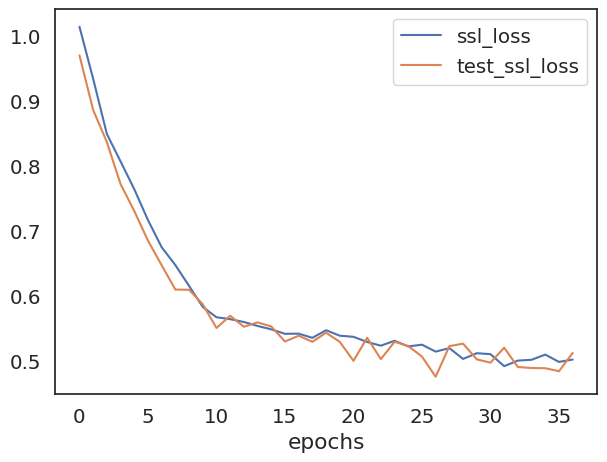

In [11]:
# =========================================================
# 8. Run pretraining
# =========================================================
pretrainer.train(
    dfcx_train=dfcx_train,
    dfcx_test=dfcx_test,
    **data_args
)

# Save pretrained model checkpoint
pretrainer.save(f'{save_dir}/pretrainer.pt')
print("Pretraining completed. Model saved to:", 
      f'{save_dir}/pretrainer.pt')